# Frozen model: final-test reproduction
The final test is already consumed. This notebook reproduces the recorded evaluation; it does not create a new untouched test or tune the model.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
ROOT = Path.cwd()
if not (ROOT / 'backend').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from backend.database import make_engine
import matplotlib.pyplot as plt


In [2]:
import joblib
from scipy.special import expit
from backend.ml.features import split_masks
from backend.ml.evaluation import metrics
frame=pd.read_csv(ROOT/'data/processed/features.csv')
test=frame.loc[split_masks(frame)['test']]
a=joblib.load(ROOT/'models/podium_model.joblib')
p=expit(a['calibration']['slope']*a['model'].decision_function(test[a['features']])+a['calibration']['intercept'])
score=metrics(test,p)
saved=json.loads((ROOT/'reports/final_test_metrics.json').read_text())
assert abs(score['log_loss']-saved['selected_model']['log_loss'])<1e-10
pd.DataFrame({k:{m:v for m,v in saved[k].items() if m!='calibration_bins'} for k in ['baseline','selected_model']})

,baseline,selected_model
rows,1359.000000,1359.000000
races,68.000000,68.000000
positive_rate,0.150110,0.150110
precision,0.755556,0.706897
recall,0.500000,0.602941
f1,0.601770,0.650794
roc_auc,0.913827,0.935364
log_loss,0.249898,0.219846
brier_score,0.073811,0.069285
top3_hit_rate,0.651961,0.647059


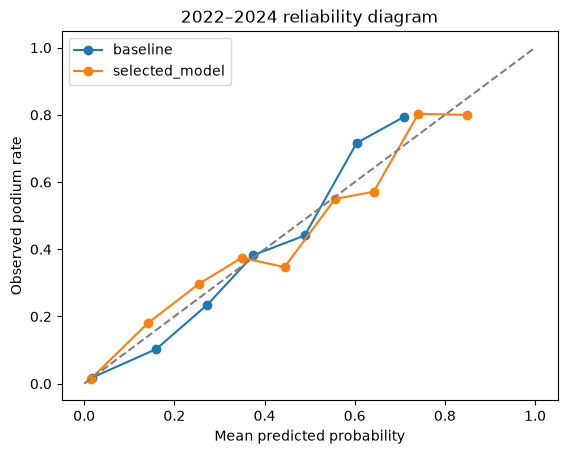

In [3]:
for name in ['baseline','selected_model']:
 bins=pd.DataFrame(saved[name]['calibration_bins']); plt.plot(bins.mean_probability,bins.observed_rate,'o-',label=name)
plt.plot([0,1],[0,1],'--',color='gray'); plt.xlabel('Mean predicted probability'); plt.ylabel('Observed podium rate'); plt.legend(); plt.title('2022–2024 reliability diagram'); plt.show()

The selected model improved log loss, Brier score and ROC-AUC, but top-three hit rate was slightly lower. Independent marginals do not sum to three. No claims of perfect prediction or live point-in-time provenance are made.